## 1. Exploratory Data Analysis (EDA)

Bu bölümde veriyi tanıyoruz: eksik değerler, kategorik/sayısal değişkenler, hedef değişkenin dağılımı ve sayısal değişkenlerin çarpıklığı (skewness) inceleniyor.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('/kaggle/input/datasets/priyamchoksi/adult-census-income-dataset/adult.csv')

print("Sütunlar:", df.columns.tolist())
df.info()
print("\nEksik değerler:\n", df.isnull().sum())

print("\n'?' içeren değerler:")
for col in df.columns:
    if df[col].dtype == 'object':
        count = (df[col].astype(str).str.strip() == '?').sum()
        if count > 0:
            print(col, count)

df.head()

Sütunlar: ['age', 'workclass', 'fnlwgt', 'education', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'income']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


`workclass`, `occupation`, `native.country` sütunlarında `'?'` olarak işaretlenmiş eksik değerler var (sırasıyla ~1836, 1843, 583 adet). Oranları düşük olduğu için mode (en sık görülen değer) ile doldurmak makul.

Kategorik: ['workclass', 'education', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'native.country', 'income']
Sayısal: ['age', 'fnlwgt', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week']

Hedef değişken değerleri: ['<=50K' '>50K']
income
<=50K    24720
>50K      7841
Name: count, dtype: int64


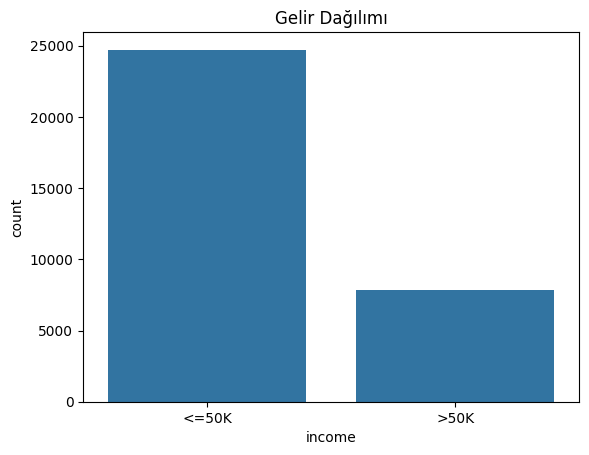

In [2]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print("Kategorik:", categorical_cols)
print("Sayısal:", numerical_cols)

print("\nHedef değişken değerleri:", df['income'].unique())
print(df['income'].value_counts())

sns.countplot(x='income', data=df)
plt.title('Gelir Dağılımı')
plt.show()

Hedef değişken dengesiz: ~%76 `<=50K`, ~%24 `>50K`. Bu, model değerlendirmesinde sadece accuracy'ye güvenmemek gerektiğini gösteriyor — precision/recall/F1 gibi metrikler de kullanılacak.

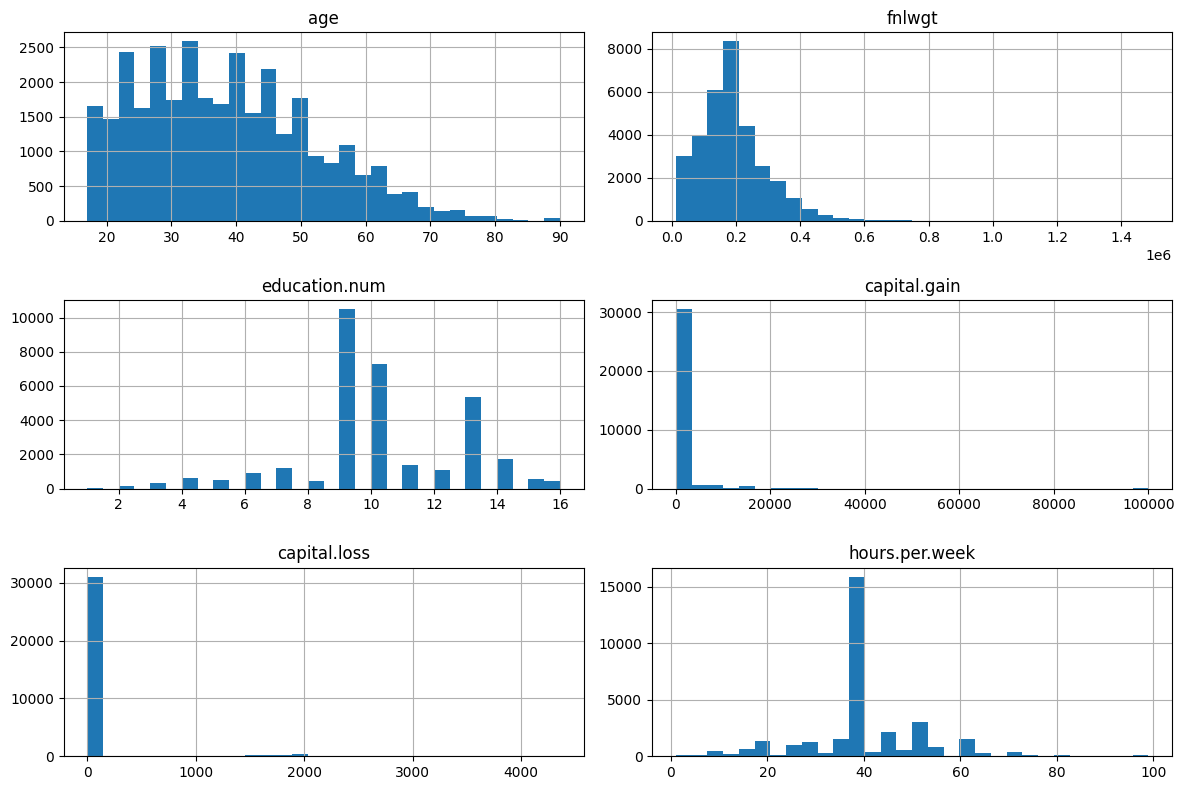

age                0.558743
fnlwgt             1.446980
education.num     -0.311676
capital.gain      11.953848
capital.loss       4.594629
hours.per.week     0.227643
dtype: float64


In [3]:
df[numerical_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

print(df[numerical_cols].skew())

`age` ve `hours.per.week` yaklaşık simetrik dağılıyor. `capital.gain` (skew ≈ 11.95) ve `capital.loss` (skew ≈ 4.59) aşırı sağa çarpık — neredeyse herkeste 0, azınlıkta yüksek değerler var. Bu gözlem, ilerideki feature engineering adımında `has_capital_gain`/`has_capital_loss` gibi binary flag'ler türetme fikrini doğurdu.

Not: Random Forest ve XGBoost gibi ağaç tabanlı modeller skewness'tan etkilenmediği için herhangi bir log-transform veya scaling uygulanmadı.

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder

# Ham veriyi baştan yükle
df = pd.read_csv('/kaggle/input/datasets/priyamchoksi/adult-census-income-dataset/adult.csv')

# Redundant sütunları at (fnlwgt: anlamsız ağırlık, education: education.num ile tekrar)
df = df.drop(['fnlwgt', 'education'], axis=1)

# '?' karakterlerini gerçek NaN yap (SimpleImputer'ın tanıması için)
df = df.replace(' ?', np.nan)
df = df.replace('?', np.nan)

print(df.isnull().sum())

age                  0
workclass         1836
education.num        0
marital.status       0
occupation        1843
relationship         0
race                 0
sex                  0
capital.gain         0
capital.loss         0
hours.per.week       0
native.country     583
income               0
dtype: int64


In [5]:
# capital.gain/loss aşırı skewed olduğu için binary flag türetiyoruz (EDA'da gördüğümüz gibi)
df['has_capital_gain'] = (df['capital.gain'] > 0).astype(int)
df['has_capital_loss'] = (df['capital.loss'] > 0).astype(int)

# Hedef değişkeni encode et
df['income'] = df['income'].map({'<=50K': 0, '>50K': 1})

X = df.drop('income', axis=1)
y = df['income']

print(X.columns.tolist())
print(X.shape, y.shape)

['age', 'workclass', 'education.num', 'marital.status', 'occupation', 'relationship', 'race', 'sex', 'capital.gain', 'capital.loss', 'hours.per.week', 'native.country', 'has_capital_gain', 'has_capital_loss']
(32561, 14) (32561,)


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

(26048, 14) (6513, 14)
income
0    0.759175
1    0.240825
Name: proportion, dtype: float64
income
0    0.759251
1    0.240749
Name: proportion, dtype: float64


In [7]:
# EDA'da belirlediğimiz sütun grupları
high_cardinality_cols = ['occupation', 'native.country']  # ordinal encoding
low_cardinality_cols = ['workclass', 'marital.status', 'relationship', 'race', 'sex']  # one-hot
numerical_cols = ['age', 'education.num', 'capital.gain', 'capital.loss', 'hours.per.week',
                   'has_capital_gain', 'has_capital_loss']

# Yüksek kardinaliteli kategorikler: eksik doldur + ordinal encode
high_card_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
])

# Düşük kardinaliteli kategorikler: eksik doldur + one-hot encode
low_card_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

# Sayısal sütunlar: dokunmuyoruz (Random Forest/XGBoost için gerek yok)
preprocessor = ColumnTransformer([
    ('high_card', high_card_pipeline, high_cardinality_cols),
    ('low_card', low_card_pipeline, low_cardinality_cols),
    ('num', 'passthrough', numerical_cols)
])

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(X_train_processed.shape, X_test_processed.shape)

(26048, 32) (6513, 32)
